In [1]:
name = "AFIBAU"
infopath = f"{name}/{name}.info"
debug=2

In [2]:
from cell2mol.read_write import readinfo
from cell2mol.classes import cell
from cell2mol.charge_assignment import *

Coordinates of the new point: [3. 4. 0.]


In [3]:
print(f"INITIATING cell object from input") 

# Reads reference molecules from info file, as well as labels and coordinates
labels, pos, ref_labels, ref_fracs, cellvec, cellparam = readinfo(infopath)
# Initiates cell
newcell = cell(name, labels, pos, cellvec, cellparam)

# Loads the reference molecules and checks_missing_H
newcell.get_reference_molecules(ref_labels, ref_fracs, debug=debug) 
newcell.assess_errors()

INITIATING cell object from input
MOLECULE.SPLIT COMPLEX: labels=['Fe', 'Si', 'Si', 'N', 'N', 'N', 'C', 'H', 'C', 'H', 'C', 'H', 'C', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'Si', 'Si', 'N', 'N', 'N', 'C', 'H', 'C', 'H', 'C', 'H', 'C', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H']
MOLECULE.SPLIT COMPLEX: metal_idx=[0]
MOLECULE.SPLIT COMPLEX: rest_idx=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 9

In [4]:
for mol in newcell.refmoleclist:
    if mol.iscomplex:
        print(mol.formula, mol.is_haptic, mol.haptic_type)
        for lig in mol.ligands:
            print(lig.formula, lig.is_haptic, lig.haptic_type)
            print(lig)
    else:
        print(mol.formula)

H60-C26-N6-Si4-Fe False []
H12-C7-N2 False []
------------- Cell2mol LIGAND Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = ligand
 Number of Atoms              = 21
 Formula                      = H12-C7-N2
 Has Adjacency Matrix         = YES
 Origin                       = split_complex
 Number of Groups             = 1
---------------------------------------------------

H18-C6-N-Si2 False []
------------- Cell2mol LIGAND Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = ligand
 Number of Atoms              = 27
 Formula                      = H18-C6-N-Si2
 Has Adjacency Matrix         = YES
 Origin                       = split_complex
 Number of Groups             = 1
---------------------------------------------------

H12-C7-N2 False []
------------- Cell2mol LIGAND Object --------------
 Version                      = 0.

In [5]:
newcell.check_missing_H(debug=debug)                                     


##################
Checking Missing H
##################
Not a Single Molecule has Missing H atoms (apparently)


False

In [6]:
newcell.reconstruct(debug=debug) 

CLASSIFY_FRAGMENTS. 36 Blocks sorted as (Molec, Frag, H): 0 24 12

##############################################
FRAG_RECONSTRUCT. 24 molecules submitted to SEQUENTIAL with Heavy
##############################################
goodlist=[]
avglist=[]
badlist=[------------- Cell2mol MOLECULE Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = Heavy
 Number of Atoms              = 2
 Formula                      = N-Si
 Has Adjacency Matrix         = YES
 Origin                       = cell.get_moleclist
---------------------------------------------------
, ------------- Cell2mol MOLECULE Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = Heavy
 Number of Atoms              = 2
 Formula                      = N-Si
 Has Adjacency Matrix         = YES
 Origin                       = cell.get_moleclist
-------------------------------------

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 97
  Formula                      = H60-C26-N6-Si4-Fe
  Has Adjacency Matrix         = YES
  Origin                       = cell.reconstruct
  Number of Ligands            = 4
  Number of Metals             = 1
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 97
  Formula                      = H60-C26-N6-Si4-Fe
  Has Adjacency Matrix         = YES
  Origin                       = cell.reconstruct
  Number of Ligands            = 4
  Number of Metals             = 1
 ---------------------------------------------------]

In [7]:
newcell.error_reconstruction

False

In [8]:
newcell.is_fragmented

False

In [9]:
newcell.assign_charges(debug=debug)

Molecule 0 formula=H60-C26-N6-Si4-Fe
New ligand found with: formula H12-C7-N2 added in position 0
COMPARE_SPECIES. Comparing:
------------- Cell2mol LIGAND Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = ligand
 Number of Atoms              = 27
 Formula                      = H18-C6-N-Si2
 Has Adjacency Matrix         = YES
 Origin                       = split_complex
---------------------------------------------------

------------- Cell2mol LIGAND Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = ligand
 Number of Atoms              = 21
 Formula                      = H12-C7-N2
 Has Adjacency Matrix         = YES
 Origin                       = split_complex
---------------------------------------------------

['Si', 'Si', 'N', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 97
  Formula                      = H60-C26-N6-Si4-Fe
  Has Adjacency Matrix         = YES
  Total Charge                 = 0
  Smiles                       = ['[H]c1nc([H])n(C(C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H])c1[H]', '[H]C([H])([H])[Si]([N-][Si](C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H]', '[H]c1nc([H])n(C(C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H])c1[H]', '[H]C([H])([H])[Si]([N-][Si](C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H]']
  Origin                       = cell.reconstruct
  Number of Ligands            = 4
  Number of Metals             = 1
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type   


    POSCHARGE will try charges [0, -1, 1, -2, 2]
smiles='[H]C([H])([H])[Si]([N-][Si](C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H]'
    POSCHARGE: charge 0 with smiles [H]C([H])([H])[Si]([N-][Si](C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H]
smiles='[H]C([H])([H])[Si]([N-][Si](C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H]'
    POSCHARGE: charge 0 with smiles [H]C([H])([H])[Si]([N-][Si](C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H]
smiles='[H]C([H])([H])[Si]([N-][Si](C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H]'
    POSCHARGE: charge 0 with smiles [H]C([H])([H])[Si]([N-][Si](C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H]
smiles='[H]C([H])([H])[Si]([N-][Si](C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H]'
    POSCHARGE: charge 0 with smiles [H]C([H])([H])[Si]([N-][Si](C([H])(

In [10]:
newcell.error_prepare_mols

False

In [11]:
newcell.moleclist

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 97
  Formula                      = H60-C26-N6-Si4-Fe
  Has Adjacency Matrix         = YES
  Total Charge                 = 0
  Smiles                       = ['[H]c1nc([H])n(C(C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H])c1[H]', '[H]C([H])([H])[Si]([N-][Si](C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H]', '[H]c1nc([H])n(C(C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H])c1[H]', '[H]C([H])([H])[Si]([N-][Si](C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H]']
  Origin                       = cell.reconstruct
  Number of Ligands            = 4
  Number of Metals             = 1
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type   

CELL.CREATE_BONDS: Creating Bonds for molecule H60-C26-N6-Si4-Fe


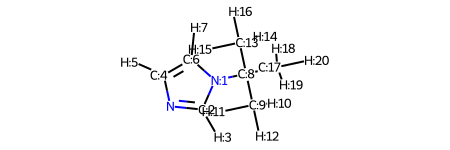

CREATE BONDS: Number of atoms in ligand object and RDKit MOL are equal: 21 21
idx=0 N Number of bonds : 2
N N : 0 , C C : 2 , 1.5
BOND CREATED 0 0 2 1.5 N C
N N : 0 , C C : 4 , 1.5
BOND CREATED 0 0 4 1.5 N C
BONDS [('N', 'C', 1.5, 1.327), ('N', 'C', 1.5, 1.375)]
idx=1 N Number of bonds : 3
N N : 1 , C C : 2 , 1.5
BOND CREATED 1 1 2 1.5 N C
N N : 1 , C C : 6 , 1.5
BOND CREATED 1 1 6 1.5 N C
N N : 1 , C C : 8 , 1.0
BOND CREATED 1 1 8 1.0 N C
BONDS [('N', 'C', 1.5, 1.34), ('N', 'C', 1.5, 1.378), ('N', 'C', 1.0, 1.491)]
idx=2 C Number of bonds : 3
N N : 0 , C C : 2 , 1.5
BOND CREATED 2 2 0 1.5 C N
N N : 1 , C C : 2 , 1.5
BOND CREATED 2 2 1 1.5 C N
C C : 2 , H H : 3 , 1.0
BOND CREATED 2 2 3 1.0 C H
BONDS [('C', 'N', 1.5, 1.327), ('C', 'N', 1.5, 1.34), ('C', 'H', 1.0, 0.93)]
idx=3 H Number of bonds : 1
C C : 2 , H H : 3 , 1.0
BOND CREATED 3 3 2 1.0 H C
BONDS [('H', 'C', 1.0, 0.93)]
idx=4 C Number of bonds : 3
N N : 0 , C C : 4 , 1.5
BOND CREATED 4 4 0 1.5 C N
C C : 4 , H H : 5 , 1.0
BOND CRE

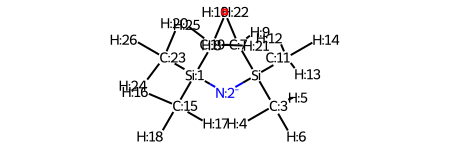

CREATE BONDS: Number of atoms in ligand object and RDKit MOL are equal: 27 27
idx=0 Si Number of bonds : 4
Si Si : 0 , N N : 2 , 1.0
BOND CREATED 0 0 2 1.0 Si N
Si Si : 0 , C C : 3 , 1.0
BOND CREATED 0 0 3 1.0 Si C
Si Si : 0 , C C : 7 , 1.0
BOND CREATED 0 0 7 1.0 Si C
Si Si : 0 , C C : 11 , 1.0
BOND CREATED 0 0 11 1.0 Si C
BONDS [('Si', 'N', 1.0, 1.708), ('Si', 'C', 1.0, 1.875), ('Si', 'C', 1.0, 1.895), ('Si', 'C', 1.0, 1.876)]
idx=1 Si Number of bonds : 4
Si Si : 1 , N N : 2 , 1.0
BOND CREATED 1 1 2 1.0 Si N
Si Si : 1 , C C : 15 , 1.0
BOND CREATED 1 1 15 1.0 Si C
Si Si : 1 , C C : 19 , 1.0
BOND CREATED 1 1 19 1.0 Si C
Si Si : 1 , C C : 23 , 1.0
BOND CREATED 1 1 23 1.0 Si C
BONDS [('Si', 'N', 1.0, 1.706), ('Si', 'C', 1.0, 1.882), ('Si', 'C', 1.0, 1.878), ('Si', 'C', 1.0, 1.887)]
idx=2 N Number of bonds : 2
Si Si : 0 , N N : 2 , 1.0
BOND CREATED 2 2 0 1.0 N Si
Si Si : 1 , N N : 2 , 1.0
BOND CREATED 2 2 1 1.0 N Si
BONDS [('N', 'Si', 1.0, 1.708), ('N', 'Si', 1.0, 1.706)]
idx=3 C Number of

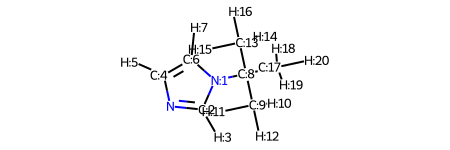

CREATE BONDS: Number of atoms in ligand object and RDKit MOL are equal: 21 21
idx=0 N Number of bonds : 2
N N : 0 , C C : 2 , 1.5
BOND CREATED 0 0 2 1.5 N C
N N : 0 , C C : 4 , 1.5
BOND CREATED 0 0 4 1.5 N C
BONDS [('N', 'C', 1.5, 1.327), ('N', 'C', 1.5, 1.375)]
idx=1 N Number of bonds : 3
N N : 1 , C C : 2 , 1.5
BOND CREATED 1 1 2 1.5 N C
N N : 1 , C C : 6 , 1.5
BOND CREATED 1 1 6 1.5 N C
N N : 1 , C C : 8 , 1.0
BOND CREATED 1 1 8 1.0 N C
BONDS [('N', 'C', 1.5, 1.34), ('N', 'C', 1.5, 1.378), ('N', 'C', 1.0, 1.491)]
idx=2 C Number of bonds : 3
N N : 0 , C C : 2 , 1.5
BOND CREATED 2 2 0 1.5 C N
N N : 1 , C C : 2 , 1.5
BOND CREATED 2 2 1 1.5 C N
C C : 2 , H H : 3 , 1.0
BOND CREATED 2 2 3 1.0 C H
BONDS [('C', 'N', 1.5, 1.327), ('C', 'N', 1.5, 1.34), ('C', 'H', 1.0, 0.93)]
idx=3 H Number of bonds : 1
C C : 2 , H H : 3 , 1.0
BOND CREATED 3 3 2 1.0 H C
BONDS [('H', 'C', 1.0, 0.93)]
idx=4 C Number of bonds : 3
N N : 0 , C C : 4 , 1.5
BOND CREATED 4 4 0 1.5 C N
C C : 4 , H H : 5 , 1.0
BOND CRE

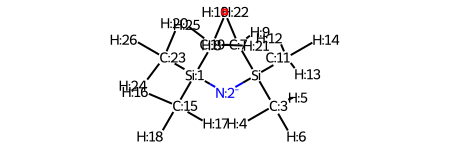

CREATE BONDS: Number of atoms in ligand object and RDKit MOL are equal: 27 27
idx=0 Si Number of bonds : 4
Si Si : 0 , N N : 2 , 1.0
BOND CREATED 0 0 2 1.0 Si N
Si Si : 0 , C C : 3 , 1.0
BOND CREATED 0 0 3 1.0 Si C
Si Si : 0 , C C : 7 , 1.0
BOND CREATED 0 0 7 1.0 Si C
Si Si : 0 , C C : 11 , 1.0
BOND CREATED 0 0 11 1.0 Si C
BONDS [('Si', 'N', 1.0, 1.708), ('Si', 'C', 1.0, 1.875), ('Si', 'C', 1.0, 1.895), ('Si', 'C', 1.0, 1.876)]
idx=1 Si Number of bonds : 4
Si Si : 1 , N N : 2 , 1.0
BOND CREATED 1 1 2 1.0 Si N
Si Si : 1 , C C : 15 , 1.0
BOND CREATED 1 1 15 1.0 Si C
Si Si : 1 , C C : 19 , 1.0
BOND CREATED 1 1 19 1.0 Si C
Si Si : 1 , C C : 23 , 1.0
BOND CREATED 1 1 23 1.0 Si C
BONDS [('Si', 'N', 1.0, 1.706), ('Si', 'C', 1.0, 1.882), ('Si', 'C', 1.0, 1.878), ('Si', 'C', 1.0, 1.887)]
idx=2 N Number of bonds : 2
Si Si : 0 , N N : 2 , 1.0
BOND CREATED 2 2 0 1.0 N Si
Si Si : 1 , N N : 2 , 1.0
BOND CREATED 2 2 1 1.0 N Si
BONDS [('N', 'Si', 1.0, 1.708), ('N', 'Si', 1.0, 1.706)]
idx=3 C Number of

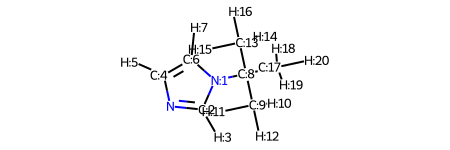

0 Si
Si N 1.0
0 2
Si C 1.0
0 3
Si C 1.0
0 7
Si C 1.0
0 11
1 Si
Si N 1.0
1 2
Si C 1.0
1 15
Si C 1.0
1 19
Si C 1.0
1 23
2 N
N Si 1.0
2 0
N Si 1.0
2 1
N Fe 0.5
3 C
C Si 1.0
3 0
C H 1.0
3 4
C H 1.0
3 5
C H 1.0
3 6
4 H
H C 1.0
4 3
5 H
H C 1.0
5 3
6 H
H C 1.0
6 3
7 C
C Si 1.0
7 0
C H 1.0
7 8
C H 1.0
7 9
C H 1.0
7 10
8 H
H C 1.0
8 7
9 H
H C 1.0
9 7
10 H
H C 1.0
10 7
11 C
C Si 1.0
11 0
C H 1.0
11 12
C H 1.0
11 13
C H 1.0
11 14
12 H
H C 1.0
12 11
13 H
H C 1.0
13 11
14 H
H C 1.0
14 11
15 C
C Si 1.0
15 1
C H 1.0
15 16
C H 1.0
15 17
C H 1.0
15 18
16 H
H C 1.0
16 15
17 H
H C 1.0
17 15
18 H
H C 1.0
18 15
19 C
C Si 1.0
19 1
C H 1.0
19 20
C H 1.0
19 21
C H 1.0
19 22
20 H
H C 1.0
20 19
21 H
H C 1.0
21 19
22 H
H C 1.0
22 19
23 C
C Si 1.0
23 1
C H 1.0
23 24
C H 1.0
23 25
C H 1.0
23 26
24 H
H C 1.0
24 23
25 H
H C 1.0
25 23
26 H
H C 1.0
26 23


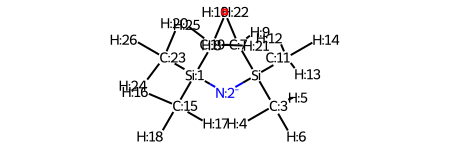

0 N
N C 1.5
0 2
N C 1.5
0 4
N Fe 0.5
1 N
N C 1.5
1 2
N C 1.5
1 6
N C 1.0
1 8
2 C
C N 1.5
2 0
C N 1.5
2 1
C H 1.0
2 3
3 H
H C 1.0
3 2
4 C
C N 1.5
4 0
C H 1.0
4 5
C C 1.5
4 6
5 H
H C 1.0
5 4
6 C
C N 1.5
6 1
C C 1.5
6 4
C H 1.0
6 7
7 H
H C 1.0
7 6
8 C
C N 1.0
8 1
C C 1.0
8 9
C C 1.0
8 13
C C 1.0
8 17
9 C
C C 1.0
9 8
C H 1.0
9 10
C H 1.0
9 11
C H 1.0
9 12
10 H
H C 1.0
10 9
11 H
H C 1.0
11 9
12 H
H C 1.0
12 9
13 C
C C 1.0
13 8
C H 1.0
13 14
C H 1.0
13 15
C H 1.0
13 16
14 H
H C 1.0
14 13
15 H
H C 1.0
15 13
16 H
H C 1.0
16 13
17 C
C C 1.0
17 8
C H 1.0
17 18
C H 1.0
17 19
C H 1.0
17 20
18 H
H C 1.0
18 17
19 H
H C 1.0
19 17
20 H
H C 1.0
20 17


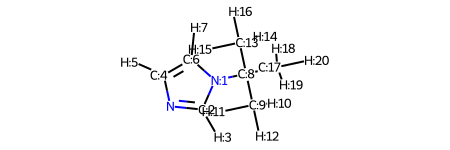

0 Si
Si N 1.0
0 2
Si C 1.0
0 3
Si C 1.0
0 7
Si C 1.0
0 11
1 Si
Si N 1.0
1 2
Si C 1.0
1 15
Si C 1.0
1 19
Si C 1.0
1 23
2 N
N Si 1.0
2 0
N Si 1.0
2 1
N Fe 0.5
3 C
C Si 1.0
3 0
C H 1.0
3 4
C H 1.0
3 5
C H 1.0
3 6
4 H
H C 1.0
4 3
5 H
H C 1.0
5 3
6 H
H C 1.0
6 3
7 C
C Si 1.0
7 0
C H 1.0
7 8
C H 1.0
7 9
C H 1.0
7 10
8 H
H C 1.0
8 7
9 H
H C 1.0
9 7
10 H
H C 1.0
10 7
11 C
C Si 1.0
11 0
C H 1.0
11 12
C H 1.0
11 13
C H 1.0
11 14
12 H
H C 1.0
12 11
13 H
H C 1.0
13 11
14 H
H C 1.0
14 11
15 C
C Si 1.0
15 1
C H 1.0
15 16
C H 1.0
15 17
C H 1.0
15 18
16 H
H C 1.0
16 15
17 H
H C 1.0
17 15
18 H
H C 1.0
18 15
19 C
C Si 1.0
19 1
C H 1.0
19 20
C H 1.0
19 21
C H 1.0
19 22
20 H
H C 1.0
20 19
21 H
H C 1.0
21 19
22 H
H C 1.0
22 19
23 C
C Si 1.0
23 1
C H 1.0
23 24
C H 1.0
23 25
C H 1.0
23 26
24 H
H C 1.0
24 23
25 H
H C 1.0
25 23
26 H
H C 1.0
26 23


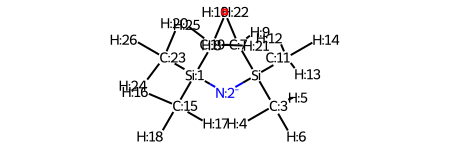

CELL.CREATE_BONDS: Creating Bonds for molecule H60-C26-N6-Si4-Fe


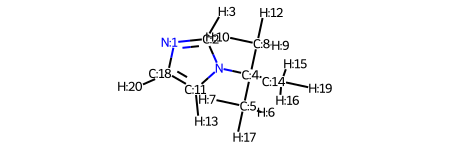

CREATE BONDS: Number of atoms in ligand object and RDKit MOL are equal: 21 21
idx=0 N Number of bonds : 3
N N : 0 , C C : 2 , 1.5
BOND CREATED 0 0 2 1.5 N C
N N : 0 , C C : 4 , 1.0
BOND CREATED 0 0 4 1.0 N C
N N : 0 , C C : 11 , 1.5
BOND CREATED 0 0 11 1.5 N C
BONDS [('N', 'C', 1.5, 1.34), ('N', 'C', 1.0, 1.491), ('N', 'C', 1.5, 1.378)]
idx=1 N Number of bonds : 2
N N : 1 , C C : 2 , 1.5
BOND CREATED 1 1 2 1.5 N C
N N : 1 , C C : 18 , 1.5
BOND CREATED 1 1 18 1.5 N C
BONDS [('N', 'C', 1.5, 1.327), ('N', 'C', 1.5, 1.375)]
idx=2 C Number of bonds : 3
N N : 0 , C C : 2 , 1.5
BOND CREATED 2 2 0 1.5 C N
N N : 1 , C C : 2 , 1.5
BOND CREATED 2 2 1 1.5 C N
C C : 2 , H H : 3 , 1.0
BOND CREATED 2 2 3 1.0 C H
BONDS [('C', 'N', 1.5, 1.34), ('C', 'N', 1.5, 1.327), ('C', 'H', 1.0, 0.93)]
idx=3 H Number of bonds : 1
C C : 2 , H H : 3 , 1.0
BOND CREATED 3 3 2 1.0 H C
BONDS [('H', 'C', 1.0, 0.93)]
idx=4 C Number of bonds : 4
N N : 0 , C C : 4 , 1.0
BOND CREATED 4 4 0 1.0 C N
C C : 4 , C C : 5 , 1.0
BOND

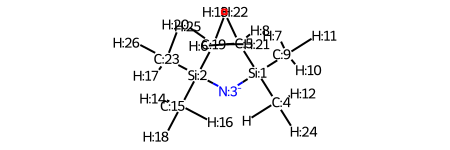

CREATE BONDS: Number of atoms in ligand object and RDKit MOL are equal: 27 27
idx=0 H Number of bonds : 1
H H : 0 , C C : 4 , 1.0
BOND CREATED 0 0 4 1.0 H C
BONDS [('H', 'C', 1.0, 0.959)]
idx=1 Si Number of bonds : 4
Si Si : 1 , N N : 3 , 1.0
BOND CREATED 1 1 3 1.0 Si N
Si Si : 1 , C C : 4 , 1.0
BOND CREATED 1 1 4 1.0 Si C
Si Si : 1 , C C : 5 , 1.0
BOND CREATED 1 1 5 1.0 Si C
Si Si : 1 , C C : 9 , 1.0
BOND CREATED 1 1 9 1.0 Si C
BONDS [('Si', 'N', 1.0, 1.708), ('Si', 'C', 1.0, 1.876), ('Si', 'C', 1.0, 1.875), ('Si', 'C', 1.0, 1.895)]
idx=2 Si Number of bonds : 4
Si Si : 2 , N N : 3 , 1.0
BOND CREATED 2 2 3 1.0 Si N
Si Si : 2 , C C : 15 , 1.0
BOND CREATED 2 2 15 1.0 Si C
Si Si : 2 , C C : 19 , 1.0
BOND CREATED 2 2 19 1.0 Si C
Si Si : 2 , C C : 23 , 1.0
BOND CREATED 2 2 23 1.0 Si C
BONDS [('Si', 'N', 1.0, 1.706), ('Si', 'C', 1.0, 1.887), ('Si', 'C', 1.0, 1.878), ('Si', 'C', 1.0, 1.882)]
idx=3 N Number of bonds : 2
Si Si : 1 , N N : 3 , 1.0
BOND CREATED 3 3 1 1.0 N Si
Si Si : 2 , N N : 3 

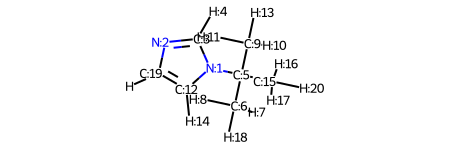

CREATE BONDS: Number of atoms in ligand object and RDKit MOL are equal: 21 21
idx=0 H Number of bonds : 1
H H : 0 , C C : 19 , 1.0
BOND CREATED 0 0 19 1.0 H C
BONDS [('H', 'C', 1.0, 0.93)]
idx=1 N Number of bonds : 3
N N : 1 , C C : 3 , 1.5
BOND CREATED 1 1 3 1.5 N C
N N : 1 , C C : 5 , 1.0
BOND CREATED 1 1 5 1.0 N C
N N : 1 , C C : 12 , 1.5
BOND CREATED 1 1 12 1.5 N C
BONDS [('N', 'C', 1.5, 1.34), ('N', 'C', 1.0, 1.491), ('N', 'C', 1.5, 1.378)]
idx=2 N Number of bonds : 2
N N : 2 , C C : 3 , 1.5
BOND CREATED 2 2 3 1.5 N C
N N : 2 , C C : 19 , 1.5
BOND CREATED 2 2 19 1.5 N C
BONDS [('N', 'C', 1.5, 1.327), ('N', 'C', 1.5, 1.375)]
idx=3 C Number of bonds : 3
N N : 1 , C C : 3 , 1.5
BOND CREATED 3 3 1 1.5 C N
N N : 2 , C C : 3 , 1.5
BOND CREATED 3 3 2 1.5 C N
C C : 3 , H H : 4 , 1.0
BOND CREATED 3 3 4 1.0 C H
BONDS [('C', 'N', 1.5, 1.34), ('C', 'N', 1.5, 1.327), ('C', 'H', 1.0, 0.93)]
idx=4 H Number of bonds : 1
C C : 3 , H H : 4 , 1.0
BOND CREATED 4 4 3 1.0 H C
BONDS [('H', 'C', 1.0, 0.9

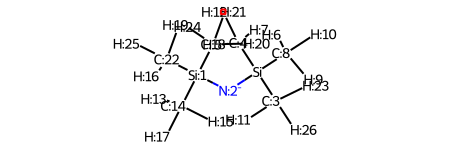

CREATE BONDS: Number of atoms in ligand object and RDKit MOL are equal: 27 27
idx=0 Si Number of bonds : 4
Si Si : 0 , N N : 2 , 1.0
BOND CREATED 0 0 2 1.0 Si N
Si Si : 0 , C C : 3 , 1.0
BOND CREATED 0 0 3 1.0 Si C
Si Si : 0 , C C : 4 , 1.0
BOND CREATED 0 0 4 1.0 Si C
Si Si : 0 , C C : 8 , 1.0
BOND CREATED 0 0 8 1.0 Si C
BONDS [('Si', 'N', 1.0, 1.708), ('Si', 'C', 1.0, 1.876), ('Si', 'C', 1.0, 1.875), ('Si', 'C', 1.0, 1.895)]
idx=1 Si Number of bonds : 4
Si Si : 1 , N N : 2 , 1.0
BOND CREATED 1 1 2 1.0 Si N
Si Si : 1 , C C : 14 , 1.0
BOND CREATED 1 1 14 1.0 Si C
Si Si : 1 , C C : 18 , 1.0
BOND CREATED 1 1 18 1.0 Si C
Si Si : 1 , C C : 22 , 1.0
BOND CREATED 1 1 22 1.0 Si C
BONDS [('Si', 'N', 1.0, 1.706), ('Si', 'C', 1.0, 1.887), ('Si', 'C', 1.0, 1.878), ('Si', 'C', 1.0, 1.882)]
idx=2 N Number of bonds : 2
Si Si : 0 , N N : 2 , 1.0
BOND CREATED 2 2 0 1.0 N Si
Si Si : 1 , N N : 2 , 1.0
BOND CREATED 2 2 1 1.0 N Si
BONDS [('N', 'Si', 1.0, 1.708), ('N', 'Si', 1.0, 1.706)]
idx=3 C Number of b

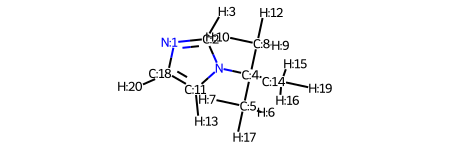

0 H
H C 1.0
0 4
1 Si
Si N 1.0
1 3
Si C 1.0
1 4
Si C 1.0
1 5
Si C 1.0
1 9
2 Si
Si N 1.0
2 3
Si C 1.0
2 15
Si C 1.0
2 19
Si C 1.0
2 23
3 N
N Si 1.0
3 1
N Si 1.0
3 2
N Fe 0.5
4 C
C H 1.0
4 0
C Si 1.0
4 1
C H 1.0
4 12
C H 1.0
4 24
5 C
C Si 1.0
5 1
C H 1.0
5 6
C H 1.0
5 8
C H 1.0
5 13
6 H
H C 1.0
6 5
7 H
H C 1.0
7 9
8 H
H C 1.0
8 5
9 C
C Si 1.0
9 1
C H 1.0
9 7
C H 1.0
9 10
C H 1.0
9 11
10 H
H C 1.0
10 9
11 H
H C 1.0
11 9
12 H
H C 1.0
12 4
13 H
H C 1.0
13 5
14 H
H C 1.0
14 15
15 C
C Si 1.0
15 2
C H 1.0
15 14
C H 1.0
15 16
C H 1.0
15 18
16 H
H C 1.0
16 15
17 H
H C 1.0
17 23
18 H
H C 1.0
18 15
19 C
C Si 1.0
19 2
C H 1.0
19 20
C H 1.0
19 21
C H 1.0
19 22
20 H
H C 1.0
20 19
21 H
H C 1.0
21 19
22 H
H C 1.0
22 19
23 C
C Si 1.0
23 2
C H 1.0
23 17
C H 1.0
23 25
C H 1.0
23 26
24 H
H C 1.0
24 4
25 H
H C 1.0
25 23
26 H
H C 1.0
26 23


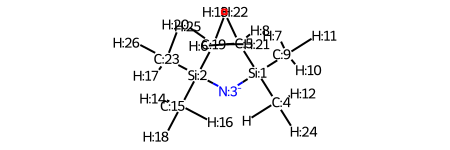

0 H
H C 1.0
0 19
1 N
N C 1.5
1 3
N C 1.0
1 5
N C 1.5
1 12
2 N
N C 1.5
2 3
N C 1.5
2 19
N Fe 0.5
3 C
C N 1.5
3 1
C N 1.5
3 2
C H 1.0
3 4
4 H
H C 1.0
4 3
5 C
C N 1.0
5 1
C C 1.0
5 6
C C 1.0
5 9
C C 1.0
5 15
6 C
C C 1.0
6 5
C H 1.0
6 7
C H 1.0
6 8
C H 1.0
6 18
7 H
H C 1.0
7 6
8 H
H C 1.0
8 6
9 C
C C 1.0
9 5
C H 1.0
9 10
C H 1.0
9 11
C H 1.0
9 13
10 H
H C 1.0
10 9
11 H
H C 1.0
11 9
12 C
C N 1.5
12 1
C H 1.0
12 14
C C 1.5
12 19
13 H
H C 1.0
13 9
14 H
H C 1.0
14 12
15 C
C C 1.0
15 5
C H 1.0
15 16
C H 1.0
15 17
C H 1.0
15 20
16 H
H C 1.0
16 15
17 H
H C 1.0
17 15
18 H
H C 1.0
18 6
19 C
C H 1.0
19 0
C N 1.5
19 2
C C 1.5
19 12
20 H
H C 1.0
20 15


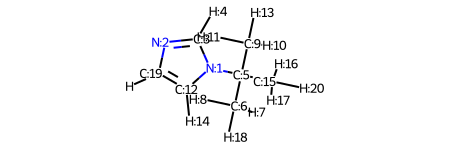

0 Si
Si N 1.0
0 2
Si C 1.0
0 3
Si C 1.0
0 4
Si C 1.0
0 8
1 Si
Si N 1.0
1 2
Si C 1.0
1 14
Si C 1.0
1 18
Si C 1.0
1 22
2 N
N Si 1.0
2 0
N Si 1.0
2 1
N Fe 0.5
3 C
C Si 1.0
3 0
C H 1.0
3 11
C H 1.0
3 23
C H 1.0
3 26
4 C
C Si 1.0
4 0
C H 1.0
4 5
C H 1.0
4 7
C H 1.0
4 12
5 H
H C 1.0
5 4
6 H
H C 1.0
6 8
7 H
H C 1.0
7 4
8 C
C Si 1.0
8 0
C H 1.0
8 6
C H 1.0
8 9
C H 1.0
8 10
9 H
H C 1.0
9 8
10 H
H C 1.0
10 8
11 H
H C 1.0
11 3
12 H
H C 1.0
12 4
13 H
H C 1.0
13 14
14 C
C Si 1.0
14 1
C H 1.0
14 13
C H 1.0
14 15
C H 1.0
14 17
15 H
H C 1.0
15 14
16 H
H C 1.0
16 22
17 H
H C 1.0
17 14
18 C
C Si 1.0
18 1
C H 1.0
18 19
C H 1.0
18 20
C H 1.0
18 21
19 H
H C 1.0
19 18
20 H
H C 1.0
20 18
21 H
H C 1.0
21 18
22 C
C Si 1.0
22 1
C H 1.0
22 16
C H 1.0
22 24
C H 1.0
22 25
23 H
H C 1.0
23 3
24 H
H C 1.0
24 22
25 H
H C 1.0
25 22
26 H
H C 1.0
26 3


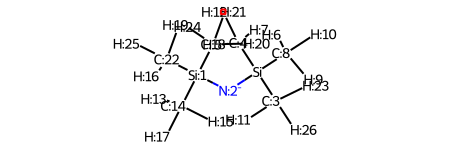

In [12]:
newcell.create_bonds(debug=debug)

In [13]:
newcell.assign_spin(debug=debug)

coord_group=[------------- Cell2mol GROUP Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = group
 Number of Atoms              = 1
 Formula                      = N
 Has Adjacency Matrix         = YES
 Origin                       = split_ligand
 Number of Metals             = 1
---------------------------------------------------
, ------------- Cell2mol GROUP Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = group
 Number of Atoms              = 1
 Formula                      = N
 Has Adjacency Matrix         = YES
 Origin                       = split_ligand
 Number of Metals             = 1
---------------------------------------------------
, ------------- Cell2mol GROUP Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = group
 Number of Atoms     

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 97
  Formula                      = H60-C26-N6-Si4-Fe
  Has Adjacency Matrix         = YES
  Total Charge                 = 0
  Spin                         = 5
  Smiles                       = ['[H]c1nc([H])n(C(C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H])c1[H]', '[H]C([H])([H])[Si]([N-][Si](C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H]', '[H]c1nc([H])n(C(C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H])c1[H]', '[H]C([H])([H])[Si]([N-][Si](C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H]']
  Origin                       = cell.reconstruct
  Number of Ligands            = 4
  Number of Metals             = 1
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version  

In [14]:
for mol in newcell.moleclist:
    if mol.iscomplex:
        print(mol.formula, mol.totcharge, mol.spin)
        for met in mol.metals:
            print(met.label, met.charge, met.spin)
            print(met.coord_nr, met.coord_geometry, met.geom_deviation, met.rel_metal_radius)

H60-C26-N6-Si4-Fe 0 5
Fe 2.0 5
4 Tetrahedral 2.066 1.037
H60-C26-N6-Si4-Fe 0 5
Fe 2.0 5
4 Tetrahedral 2.066 1.037


In [ ]:
newcell.get_unique_species(debug=debug)

In [ ]:
selected_cs = []
for idx, spec in enumerate(newcell.unique_species):
#     print("doing", spec)
    if spec.subtype != "metal":
        spec.get_protonation_states()
        spec.get_possible_cs()
        print(spec.formula)
        selected_cs.append(list([cs.corr_total_charge for cs in spec.possible_cs]))
        print(f"{spec.protonation_states=}")
    else :
        spec.get_possible_cs()
        selected_cs.append(spec.possible_cs)   
    print("")
print(selected_cs)

In [ ]:
final_charge_distribution = balance_charge(newcell.unique_indices, newcell.unique_species, debug=debug)